In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd                    # pandas is the "python data analysis package"
import os                              # operating system services
from scipy.optimize import curve_fit   # non-linear curve fitting

np.random.seed(0)                      # set the random seed for reproducibility

In [3]:
df = pd.read_csv("discharge.csv") # load the CSV file
df.head() # Displays the CSV files

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,Capacity,id_cycle,type,ambient_temperature,time,Battery
0,3.974871,-2.012528,24.389085,1.9982,3.062,35.703,1.856487,1,discharge,24,2008.0,B0005
1,3.951717,-2.013979,24.544752,1.9982,3.030,53.781,1.856487,1,discharge,24,2008.0,B0005
2,3.934352,-2.011144,24.731385,1.9982,3.011,71.922,1.856487,1,discharge,24,2008.0,B0005
3,3.920058,-2.013007,24.909816,1.9982,2.991,90.094,1.856487,1,discharge,24,2008.0,B0005
4,3.907904,-2.014400,25.105884,1.9982,2.977,108.281,1.856487,1,discharge,24,2008.0,B0005


In [4]:
df.columns # shows the index of the file, this allows for calling data

Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_charge', 'Voltage_charge', 'Time', 'Capacity', 'id_cycle',
       'type', 'ambient_temperature', 'time', 'Battery'],
      dtype='object')

In [5]:
cycle_number = 1 # chooses what cycle to analyze
df_cycle = df[df["id_cycle"] == cycle_number] # filters rows that match the chosen cycle and are part of the discharge phase

# Extract time and voltage as a numpy array
t = df_cycle["Time"].values
V = df_cycle["Voltage_measured"].values

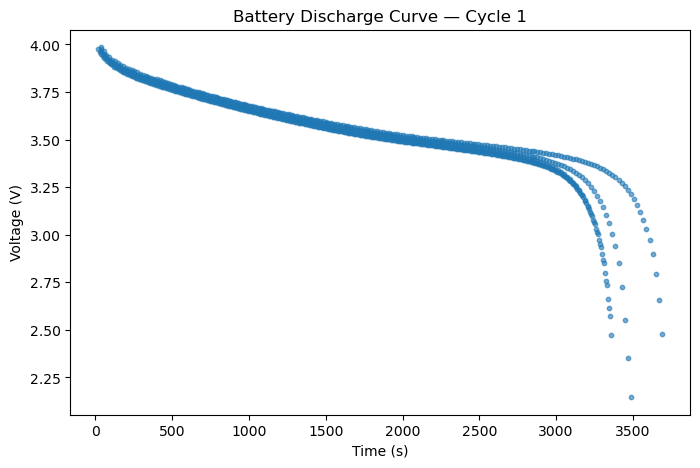

In [6]:
#Plots Raw data discharge
plt.figure(figsize=(8,5))
plt.scatter(t, V, s=10, alpha=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"Battery Discharge Curve — Cycle {cycle_number}")
plt.show()

In [7]:
def discharge_model(t, V_inf, A, tau):
    return V_inf + A * np.exp(-t / tau)
# V(t) = V_final + A (Inital Voltage drop) * exp(-t/ Tau)


p0 = [3.0, 1.0, 500.0]  # initial guesses

popt, pcov = curve_fit(discharge_model, t, V, p0=p0) # Fit the model to the data


V_inf, A, tau = popt # Extract fitted parameters

sigma_V_inf, sigma_A, sigma_tau = np.sqrt(np.diag(pcov)) # Extract uncertainties from the covariance matrix


print("Fitted parameters:")
print(f"V_inf = {V_inf:.4f} ± {sigma_V_inf:.4f} V")
print(f"A     = {A:.4f} ± {sigma_A:.4f} V")
print(f"tau   = {tau:.2f} ± {sigma_tau:.2f} s")


Fitted parameters:
V_inf = -6987.3640 ± 466301.8847 V
A     = 6991.2614 ± 466301.8830 V
tau   = 34142159.84 ± 2277282698.99 s


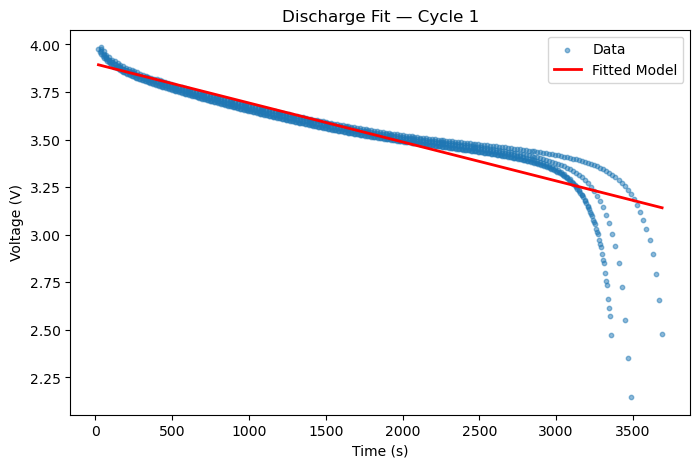

In [8]:
# Generates a time axis for plotting curve fit
t_fit = np.linspace(t.min(), t.max(), 500)
V_fit = discharge_model(t_fit, *popt)
# plots raw data with fitted model
plt.figure(figsize=(8,5))
plt.scatter(t, V, s=10, alpha=0.5, label="Data")
plt.plot(t_fit, V_fit, 'r-', linewidth=2, label="Fitted Model")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title(f"Discharge Fit — Cycle {cycle_number}")
plt.legend()
plt.show()

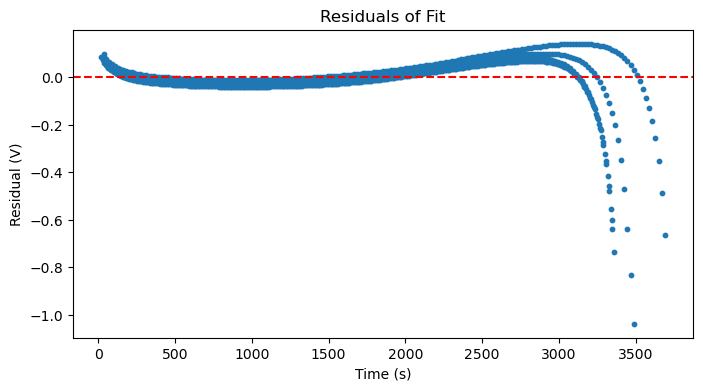

In [9]:
residuals = V - discharge_model(t, *popt) # computed residual

#plots residuals to check for errors
plt.figure(figsize=(8,4))
plt.scatter(t, residuals, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Residual (V)")
plt.title("Residuals of Fit")
plt.show()

In [10]:
N_boot = 300 # Numbers generated
params_boot = [] # Store fitted parameters from each bootstrap run

res_std = np.std(residuals) # Estimate noise level from residuals
rng = np.random.default_rng(0)# Random number generator for reproducibility


for _ in range(N_boot):
    noise = rng.normal(0, res_std, size=len(t))     # random noise
    V_synth = discharge_model(t, *popt) + noise     # model + noise
    popt_boot, _ = curve_fit(discharge_model, t, V_synth, p0=popt)     # Fit the model to the synthetic dataset
    params_boot.append(popt_boot)     # Store the fitted parameters

# Convert to array 
params_boot = np.array(params_boot)

# Standard deviation across bootstrap fits = uncertainty estimate
boot_std = params_boot.std(axis=0)

print("Bootstrap uncertainties:")
print(f"V_inf std = {boot_std[0]:.4f}")
print(f"A std     = {boot_std[1]:.4f}")
print(f"tau std   = {boot_std[2]:.2f}")

Bootstrap uncertainties:
V_inf std = 311131.8252
A std     = 311131.8251
tau std   = 1517598927.30
